Loading data
Loaded 8,020 rows * 20 cols
date rnage 2008-02-12 --> 2016-09-17
Wells : <ArrowStringArray>
['15/9-F-12', '15/9-F-14', '15/9-F-11', '15/9-F-15 D', '15/9-F-1 C',
 '15/9-F-5']
Length: 6, dtype: str
	Wells Found: 
['15/9-F-12', '15/9-F-14', '15/9-F-11', '15/9-F-15 D', '15/9-F-1 C', '15/9-F-5']

Generating Plot 1: Raw daily production decline...
Saved PNG --> ../outputs/figures/01_raw_prod_decline.png
	 Generating  Plot 2 : Monthly Avg decline, ARPS 
Saved = > ../outputs/figures/02_Monthly_Decline.png
	 generating Plot 3 : GOR over time.
saved -> ../outputs/figures/03_gor_month_overtime.png
	 Generating plot 4
Saved --> ../outputs/figures/04_water_cut.png
	 Generating Plot 5 : coorelation HeatMap:


ValueError: keyword lablesize is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_c

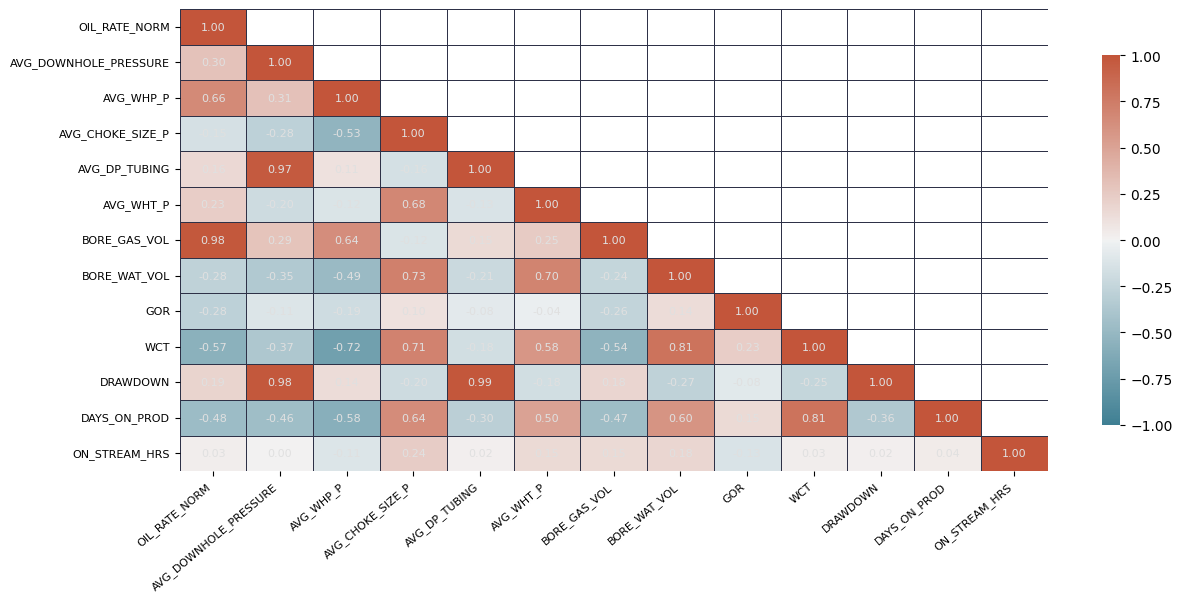

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import seaborn as sns

WELL_COLOURS = {
    '15/9-F-1 C':   '#f39c12',   # amber
    '15/9-F-11':    '#3498db',   # blue
    '15/9-F-12':    '#2ecc71',   # green   
    '15/9-F-14':    '#e74c3c',   # red
    '15/9-F-15 D':  '#9b59b6',   # purple
    '15/9-F-5':     '#1abc9c',   # teal
}
# BG    = '#0f1117' 
BG = '#ffffff'  
MUTED = '#888888'  
TEXT  = '#e0e0e0'   # off-white text

OUTPUT_DIR = '../outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Helper function 
def style_ax(ax, title, xlabel='', ylabel='', fontsize=12):
    ax.set_title(title, fontsize=fontsize, fontweight='bold',color=TEXT, pad=10)
    ax.set_xlabel(xlabel, fontsize=10, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=10, color=MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2e3147')
 


print("Loading data")
df = pd.read_parquet('../data/processed/cleaned.parquet')
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])
df = df.set_index('DATEPRD').sort_index()

df['OIL_RATE_NORM'] = df.groupby('NPD_WELL_BORE_NAME')['OIL_RATE_NORM'].transform(
    lambda x: x.clip(upper=x.quantile(0.99))
)
print(f"Loaded {df.shape[0]:,} rows * {df.shape[1]:,} cols")
print(f"date rnage {df.index.min().date()} --> {df.index.max().date()}")
print(f"Wells : {df['NPD_WELL_BORE_NAME'].unique()}")



well_groups = df.groupby('NPD_WELL_BORE_NAME')
wells = list(df['NPD_WELL_BORE_NAME'].unique())
print(f"\tWells Found: \n{wells}")


print("\nGenerating Plot 1: Raw daily production decline...")
 
fix,ax = plt.subplots(figsize=(14,6),facecolor = BG)

for well_name,well_df in well_groups:
    colour = WELL_COLOURS.get(well_name, '#ffffff')

    ax.plot(well_df.index,                # X - axis
            well_df['OIL_RATE_NORM'],     # Y - axis
            color = colour,       # Color 
            alpha = 0.25,          # transparent 
            linewidth = 0.8,    # thin line
            label = '_nolegend_')       
    
    rolling_mean = well_df['OIL_RATE_NORM'].rolling(window=30,min_periods=7).mean()            # to create smooth signal

    ax.plot(well_df.index,
            rolling_mean,
            color = colour,
            alpha =0.95,
            linewidth = 2.0,
            label = well_name)
    
for well_name, well_df in well_groups:
    colour = WELL_COLOURS.get(well_name, '#ffffff')
    peak_idx = well_df['OIL_RATE_NORM'].idxmax()
    peak_val = well_df['OIL_RATE_NORM'].max()
    ax.annotate(f'{peak_val:.0f}',
                xy=(peak_idx,peak_val),
                fontsize= 7,
                color = colour,
                alpha = 0.8,
                xytext= (0, 6),
                textcoords='offset points',
                ha = 'center'
                )

 
style_ax(ax,
         title='Daily Oil Production Rate — All Wells (Sm³/day)',
         xlabel='Date',
         ylabel='Oil Rate (Sm³/day, 24hr normalised)')
    
 
ax.legend(loc='upper right', fontsize =9, framealpha = 0.4)
plt.tight_layout()
path = f'{OUTPUT_DIR}/01_raw_prod_decline.png'
fix.savefig(path,dpi =150 ,bbox_inches ='tight',facecolor = BG)
plt.close()
print(f"Saved PNG --> {path}")

## ARPS Decline
## forcast future production

print("\t Generating  Plot 2 : Monthly Avg decline, ARPS ")
fig, axes = plt.subplots(1,2,figsize = (16,6),facecolor =BG)

for well_name ,  well_df in well_groups:
    colour = WELL_COLOURS.get(well_name,'#ffffff')

    monthly = well_df['OIL_RATE_NORM'].resample('ME').mean().dropna()

    axes[0].plot(monthly.index, 
                 monthly.values,
                 color =colour,
                 linewidth = 2,
                 marker = 'o',
                 markersize = 3,
                 alpha =0.85,
                 label = well_name)
    
    if (monthly.values > 0).all():
        axes[1].semilogy(monthly.index, 
                         monthly.values, 
                         color = colour, 
                         linewidth = 2,
                         marker = 'o',
                         markersize = 3,
                         alpha =0.85,
                         label = well_name)

              
style_ax(axes[0],title='Monthly Avg Oil Rate -- Liner Scale',xlabel='Date',ylabel='Avg oil Rate')
style_ax(axes[1],title='Monthly Avg oil -- Log Scale',xlabel='Date',ylabel='Avg oil Rate(sm^3/day  -- Log)')

axes[0].legend(fontsize = 8, framealpha = 0.4)
axes[1].legend(fontsize = 8, framealpha = 0.4)

plt.tight_layout()
path=f'{OUTPUT_DIR}/02_Monthly_Decline.png'
fig.savefig(path,dpi =150 ,bbox_inches ='tight',facecolor = BG)
plt.close()
print(f"Saved = > {path}")


print("\t generating Plot 3 : GOR over time.")
fig,ax = plt.subplots(figsize=(14,6) , facecolor = BG)


for well_name, well_df in well_groups:
    colour = WELL_COLOURS.get(well_name, '#ffffff')
    #clip means tto capp at 5000, median to avoid outliners, dropna to drop if not valid data
    gor_monthly = well_df['GOR'].clip(upper=5000).resample('ME').median().dropna()     

    ax.plot(gor_monthly.index,
            gor_monthly.values,
            color = colour,
            linewidth = 2,
            alpha = 0.85,
            label = well_name)
    # ax.fill_between(gor_monthly.index,
    #                 gor_monthly.values,
    #                 alpha = 0.08,
    #                 color =colour)
    
style_ax(ax,title='Gas - oil Ratio - Monthly median\n Rising GOR', xlabel='Date',ylabel='GOR (Sm^3 gas / Sm3 oil)')
ax.legend(loc='upper left',fontsize = 9 , framealpha = 0.4)
plt.tight_layout()
path = f'{OUTPUT_DIR}/03_gor_month_overtime.png'
fig.savefig(path,dpi = 150 , bbox_inches='tight',facecolor = BG)
plt.close()
print(f"saved -> {path}")

## WCT another feature for our model as if it pumps more than 0.7 , it is uneconomic .
## WCT is between 0.0 - 1.0

print("\t Generating plot 4")

fig, ax = plt.subplots(figsize = (14,6) , facecolor = BG)
for well_name, well_df in well_groups:
    colour = WELL_COLOURS.get(well_name,'#ffffff')
    wct_monthly = well_df['WCT'].resample('ME').mean().dropna()

    ax.plot(wct_monthly.index,
            wct_monthly.values,
            color = colour,
            linewidth = 2,
            alpha=0.85,
            label = well_name)
ax.axhline(0.5,color='#f39c12',linestyle = '--',
               linewidth =1,
               alpha=0.5, label='50% Water Cut')

ax.axhline(0.8,color='#e74c3c',linestyle = '--',
               linewidth =1,
               alpha=0.5, label='80% Water Cut')
ax.set_ylim(0,1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x ,_:f'{x:.0%}'))
style_ax(ax,
         title='WCT overr time- Monthly avg',
         xlabel='Date',
         ylabel='Water Cut')
ax.legend(loc='upper left',fontsize = 9,framealpha = 0.4)
plt.tight_layout()
path=f'{OUTPUT_DIR}/04_water_cut.png'
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor=BG)
plt.close()
print(f'Saved --> {path}')

print(f"\t Generating Plot 5 : coorelation HeatMap:")

feature_col = [
    'BORE_OIL_VAL',             # TARGET
    'OIL_RATE_NORM',            #NORMALIZED TARGET
    'AVG_DOWNHOLE_PRESSURE',    #RESERVOIR ENGERGY
    'AVG_WHP_P',                #WELL HEAD PRESSURE
    'AVG_CHOKE_SIZE_P',         #OPERATIONAL CONTROLLED VARIABLE
    'AVG_DP_TUBING',            #FLOW INDICATOR
    'AVG_WHT_P',                #WELLHEAD TEMPREATURE
    'BORE_GAS_VOL',             # GAS VOL
    'BORE_WAT_VOL',             # WATER VOL 
    'GOR',                      # GAS OIL RATIO (E)
    'WCT',                      # WATER CUT   (E)
    'DRAWDOWN',                 #PRESSURE DIFFERNTAL (e)
    'DAYS_ON_PROD',             #WELL AGE (E)
    'ON_STREAM_HRS'             #HOURS RUNNING
]

feature_col = [c for c in feature_col if c in df.columns]
coor_df = df[feature_col].corr()       # creates a table of correlated they are.

mask = np.triu(np.ones_like(coor_df,dtype=bool),k=1) 

fig, ax= plt.subplots(figsize=(14,6),facecolor = BG)


cmap = sns.diverging_palette(220,20,as_cmap=True)

sns.heatmap(
    coor_df,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size':8 , 'color':TEXT},
    linewidths=0.5,
    linecolor='#2e3147',
    cbar_kws={'shrink' : 0.8},
    ax=ax
)         
   
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=40,
                   ha='right',
                   fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0,
                   fontsize= 8)
ax.collections[0].colorbar.ax.tick_params(
    labelcolor=TEXT , labelsize =8
)

style_ax(ax,
         title='Coorelation Heatmap \nnFocus on BORE_OIL_VOL to find strongest prodictor')

plt.tight_layout()
path=f'{OUTPUT_DIR}/05_coorelation_heatmap.png'
fig.savefig(path,dpi=150,bbox_inches ='tight',facecolor=BG)
plt.close()
print(f'Saved -> {path}')